# 02 — Val/Test Distribution Shift Diagnosis

**Síntoma:** Transformer S2 → val F0.5=0.683 (p85) pero test F0.5=0.345.  
AUC-ROC se mantiene (0.803 → 0.779) → el modelo discrimina, pero el umbral no viaja.

**Hipótesis a verificar:**
1. ¿Los canales (CADC*) están distribuidos igual en val y test?
2. ¿Las distribuciones de error de reconstrucción de val_anomaly y test_anomaly son distintas?
3. ¿Las series temporales de anomalías bien detectadas (val) y mal detectadas (test) son visualmente distintas?

**No se cambia nada del modelo. Solo diagnóstico.**

In [1]:
import sys
from pathlib import Path

# Notebook está en notebooks/ → subir un nivel para importar src/
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde
import torch

from src.data.loader import (
    load_opssat_segments,
    make_sliding_windows,
    segment_scores_from_windows,
    WindowDataset,
)
from src.models.transformer_ad import (
    TransformerReconstructionAD,
    build_dataloader,
    train_epoch,
    window_reconstruction_errors,
)
from src.evaluation.metrics import compute_metrics

# Mismos hiperparámetros que run_threshold_sweep.py
CFG = dict(
    window_size = 64,
    stride      = 32,
    sampling    = 5,
    d_model     = 64,
    n_heads     = 4,
    n_layers    = 2,
    d_ff        = 128,
    dropout     = 0.1,
    lr          = 1e-3,
    batch_size  = 64,
    epochs      = 30,
    val_frac    = 0.2,
    score_agg   = "max",
    seed        = 42,
)

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
device = torch.device("cpu")
print(f"ROOT: {ROOT}")
print(f"PyTorch {torch.__version__} | device: {device}")

ROOT: /Users/macbook/Desktop/anomaly-internal-detection
PyTorch 2.11.0 | device: cpu


## Setup: reproducir el split 3-way exacto de run_threshold_sweep.py

In [2]:
# ── Reproducir build_splits() ─────────────────────────────────────────────────
rng = np.random.default_rng(CFG["seed"])

# Cargar todos los segmentos del split train (sampling=5)
all_train = make_sliding_windows(
    window_size          = CFG["window_size"],
    stride               = CFG["stride"],
    sampling_rate_filter = CFG["sampling"],
    split                = "train",
    train_normal_only    = False,
)

normal_seg_ids  = np.unique(all_train.seg_ids[all_train.labels == 0])
anomaly_seg_ids = np.unique(all_train.seg_ids[all_train.labels == 1])

# 80/20 sobre normales → train_normal + val_normal
shuffled = rng.permutation(normal_seg_ids)
n_train  = int(len(shuffled) * (1 - CFG["val_frac"]))
train_normal_ids = shuffled[:n_train]
val_normal_ids   = shuffled[n_train:]

mask_train = np.isin(all_train.seg_ids, train_normal_ids)
train_normal_windows = all_train.windows[mask_train]

val_seg_ids = np.concatenate([val_normal_ids, anomaly_seg_ids])
mask_val    = np.isin(all_train.seg_ids, val_seg_ids)
val_ds = WindowDataset(
    windows     = all_train.windows[mask_val],
    labels      = all_train.labels[mask_val],
    seg_ids     = all_train.seg_ids[mask_val],
    window_size = CFG["window_size"],
)

test_ds = make_sliding_windows(
    window_size          = CFG["window_size"],
    stride               = CFG["stride"],
    sampling_rate_filter = CFG["sampling"],
    split                = "test",
)

# IDs de segmentos por grupo
val_normal_window_ids  = val_ds.seg_ids[val_ds.labels == 0]
val_anomaly_window_ids = val_ds.seg_ids[val_ds.labels == 1]
val_normal_segs  = np.unique(val_normal_window_ids)
val_anomaly_segs = np.unique(val_anomaly_window_ids)
test_normal_segs  = np.unique(test_ds.seg_ids[test_ds.labels == 0])
test_anomaly_segs = np.unique(test_ds.seg_ids[test_ds.labels == 1])

print(f"train_normal : {len(train_normal_windows):>5} ventanas | {len(train_normal_ids):>4} segmentos")
print(f"val_normal   : {(val_ds.labels==0).sum():>5} ventanas | {len(val_normal_segs):>4} segmentos")
print(f"val_anomaly  : {(val_ds.labels==1).sum():>5} ventanas | {len(val_anomaly_segs):>4} segmentos")
print(f"test_normal  : {(test_ds.labels==0).sum():>5} ventanas | {len(test_normal_segs):>4} segmentos")
print(f"test_anomaly : {(test_ds.labels==1).sum():>5} ventanas | {len(test_anomaly_segs):>4} segmentos")

train_normal :   277 ventanas |  154 segmentos
val_normal   :    53 ventanas |   39 segmentos
val_anomaly  :    67 ventanas |   35 segmentos
test_normal  :    97 ventanas |   61 segmentos
test_anomaly :    26 ventanas |   11 segmentos


---
## Pregunta 1 — ¿Mismos canales en val y test?

Cuenta segmentos normales y anómalos por canal en cada grupo.  
Si hay canales que aparecen en test pero no en val (o con distribuciones muy distintas) → el modelo nunca vio ese tipo de señal.

In [3]:
# Cargar metadata de segmentos (canal, sampling, anomaly, train)
seg_df = load_opssat_segments()
seg_meta = (
    seg_df.groupby("segment")[["channel", "anomaly", "train", "sampling"]]
    .first()
    .reset_index()
)

# Filtrar a sampling=5 (igual que el modelo)
seg_meta5 = seg_meta[seg_meta["sampling"] == CFG["sampling"]].copy()

# Asignar grupo
def assign_group(row):
    sid = row["segment"]
    if sid in train_normal_ids:
        return "train_normal"
    elif sid in val_normal_segs:
        return "val_normal"
    elif sid in val_anomaly_segs:
        return "val_anomaly"
    elif sid in test_normal_segs:
        return "test_normal"
    elif sid in test_anomaly_segs:
        return "test_anomaly"
    else:
        return "excluded"  # segmentos demasiado cortos (< window_size)

seg_meta5["group"] = seg_meta5.apply(assign_group, axis=1)

# Contar por canal y grupo
counts = (
    seg_meta5[seg_meta5["group"] != "excluded"]
    .groupby(["channel", "group"])
    .size()
    .unstack(fill_value=0)
)

# Ordenar columnas para legibilidad
col_order = [c for c in ["train_normal", "val_normal", "val_anomaly", "test_normal", "test_anomaly"] if c in counts.columns]
counts = counts[col_order]
print(counts.to_string())

group     train_normal  val_normal  val_anomaly  test_normal  test_anomaly
channel                                                                   
CADC0872            19           4           15            5             8
CADC0873            22           2            7           10             3
CADC0874            21           3            0           12             0
CADC0884            64          22            0           24             0
CADC0888            28           8           11           10             0
CADC0894             0           0            2            0             0


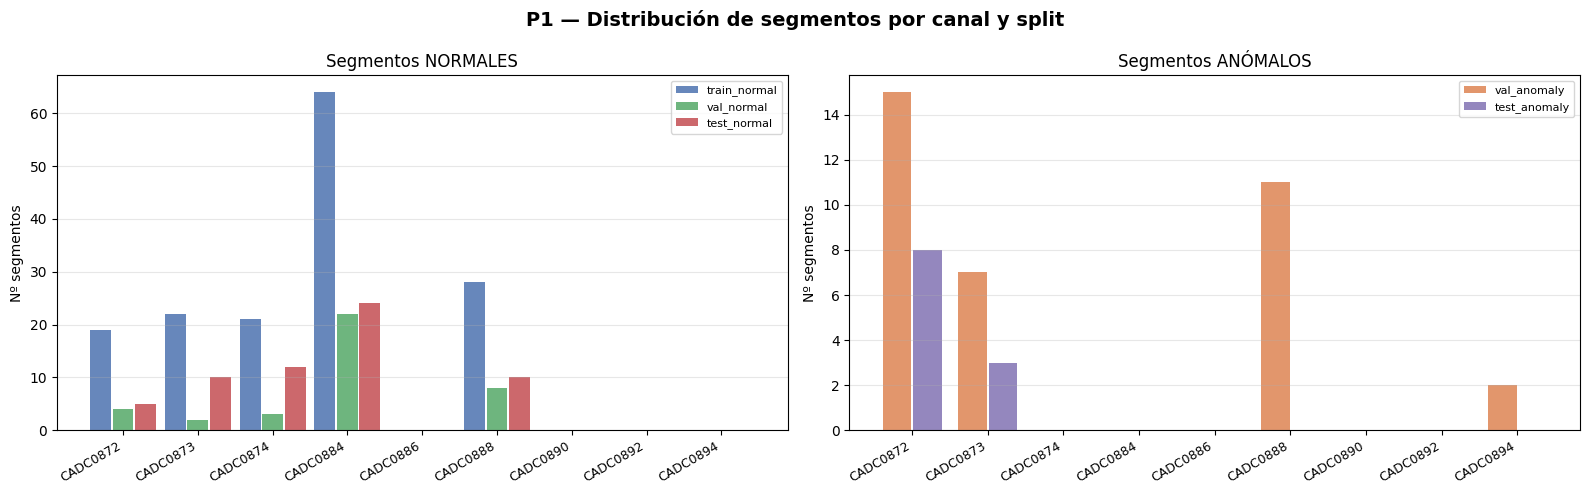


Canales anómalos compartidos  : ['CADC0872', 'CADC0873']
Solo en val_anomaly           : ['CADC0888', 'CADC0894']
Solo en test_anomaly          : []


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("P1 — Distribución de segmentos por canal y split", fontsize=14, fontweight="bold")

channels = sorted(seg_meta5["channel"].unique())
x        = np.arange(len(channels))
width    = 0.35

# Subplot izq: normal
ax = axes[0]
ax.set_title("Segmentos NORMALES")
normal_groups  = ["train_normal", "val_normal", "test_normal"]
normal_colors  = ["#4C72B0", "#55A868", "#C44E52"]
normal_offsets = np.linspace(-0.3, 0.3, len(normal_groups))
for offset, grp, color in zip(normal_offsets, normal_groups, normal_colors):
    vals = [counts.loc[ch, grp] if ch in counts.index and grp in counts.columns else 0 for ch in channels]
    ax.bar(x + offset, vals, 0.28, label=grp, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Nº segmentos")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

# Subplot der: anomaly
ax = axes[1]
ax.set_title("Segmentos ANÓMALOS")
anomaly_groups  = ["val_anomaly", "test_anomaly"]
anomaly_colors  = ["#DD8452", "#8172B3"]
anomaly_offsets = [-0.2, 0.2]
for offset, grp, color in zip(anomaly_offsets, anomaly_groups, anomaly_colors):
    vals = [counts.loc[ch, grp] if ch in counts.index and grp in counts.columns else 0 for ch in channels]
    ax.bar(x + offset, vals, 0.38, label=grp, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Nº segmentos")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/02_p1_channel_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Resumen: ¿hay canales exclusivos de test_anomaly?
if "val_anomaly" in counts.columns and "test_anomaly" in counts.columns:
    val_anom_channels  = set(counts.index[counts["val_anomaly"]  > 0])
    test_anom_channels = set(counts.index[counts["test_anomaly"] > 0])
    only_in_test = test_anom_channels - val_anom_channels
    only_in_val  = val_anom_channels  - test_anom_channels
    shared       = val_anom_channels  & test_anom_channels
    print(f"\nCanales anómalos compartidos  : {sorted(shared)}")
    print(f"Solo en val_anomaly           : {sorted(only_in_val)}")
    print(f"Solo en test_anomaly          : {sorted(only_in_test)}")
    if only_in_test:
        print("  ⚠️  El modelo NUNCA vio anomalías de estos canales durante entrenamiento/validación.")

---
## Entrenar el modelo (mismo config que threshold sweep)

Necesitamos las puntuaciones de reconstrucción para P2 y P3.  
Config idéntico a `run_threshold_sweep.py` con seed=42.

In [5]:
torch.manual_seed(CFG["seed"])

model = TransformerReconstructionAD(
    seq_len  = CFG["window_size"],
    d_model  = CFG["d_model"],
    n_heads  = CFG["n_heads"],
    n_layers = CFG["n_layers"],
    d_ff     = CFG["d_ff"],
    dropout  = CFG["dropout"],
).to(device)

n_params  = sum(p.numel() for p in model.parameters())
optimizer = torch.optim.Adam(model.parameters(), lr=CFG["lr"])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG["epochs"], eta_min=CFG["lr"] * 0.01
)
train_dl  = build_dataloader(train_normal_windows, CFG["batch_size"], shuffle=True)

print(f"Entrenando {n_params:,} parámetros × {CFG['epochs']} epochs ...")
losses = []
for ep in range(1, CFG["epochs"] + 1):
    loss = train_epoch(model, train_dl, optimizer, device)
    scheduler.step()
    losses.append(loss)
    if ep % 10 == 0 or ep == 1:
        print(f"  epoch {ep:>3}  MSE={loss:.6f}")

print(f"\nLoss: {losses[0]:.4f} → {losses[-1]:.4f}  (drop {(losses[0]-losses[-1])/losses[0]:.1%})")

# ── Errores de reconstrucción por ventana ─────────────────────────────────────
print("\nCalculando errores de reconstrucción ...")
train_errors = window_reconstruction_errors(model, train_normal_windows, CFG["batch_size"], device)
val_errors   = window_reconstruction_errors(model, val_ds.windows,       CFG["batch_size"], device)
test_errors  = window_reconstruction_errors(model, test_ds.windows,      CFG["batch_size"], device)

# Separar por grupo
val_normal_mask  = val_ds.labels == 0
val_anomaly_mask = val_ds.labels == 1
test_normal_mask  = test_ds.labels == 0
test_anomaly_mask = test_ds.labels == 1

val_normal_errors  = val_errors[val_normal_mask]
val_anomaly_errors = val_errors[val_anomaly_mask]
test_normal_errors  = test_errors[test_normal_mask]
test_anomaly_errors = test_errors[test_anomaly_mask]

# Umbral óptimo en val (p85)
best_threshold = float(np.percentile(train_errors, 85))
print(f"\nUmbral p85 (train-normal) = {best_threshold:.6f}")

# Verificar que replicamos los resultados conocidos
uid_val, sc_val = segment_scores_from_windows(val_errors, val_ds.seg_ids, agg="max")
lbl_val = np.array([val_ds.labels[val_ds.seg_ids == sid][0] for sid in uid_val])
m_val   = compute_metrics(lbl_val, (sc_val > best_threshold).astype(int), sc_val)

uid_test, sc_test = segment_scores_from_windows(test_errors, test_ds.seg_ids, agg="max")
lbl_test = np.array([test_ds.labels[test_ds.seg_ids == sid][0] for sid in uid_test])
m_test   = compute_metrics(lbl_test, (sc_test > best_threshold).astype(int), sc_test)

print(f"\nVal  F0.5={m_val['f05']:.3f}  AUC={m_val['auc_roc']:.3f}  (esperado: F0.5≈0.683, AUC≈0.803)")
print(f"Test F0.5={m_test['f05']:.3f}  AUC={m_test['auc_roc']:.3f}  (esperado: F0.5≈0.345, AUC≈0.779)")

/Users/macbook/Desktop/anomaly-internal-detection/src/models/transformer_ad.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)


Entrenando 71,233 parámetros × 30 epochs ...
  epoch   1  MSE=0.673162


  epoch  10  MSE=0.008334


  epoch  20  MSE=0.005263


  epoch  30  MSE=0.004840

Loss: 0.6732 → 0.0048  (drop 99.3%)

Calculando errores de reconstrucción ...

Umbral p85 (train-normal) = 0.000932

Val  F0.5=0.683  AUC=0.803  (esperado: F0.5≈0.683, AUC≈0.803)
Test F0.5=0.345  AUC=0.779  (esperado: F0.5≈0.345, AUC≈0.779)


---
## Pregunta 2 — ¿Mismos tipos de anomalía?

Si `val_anomaly_errors` y `test_anomaly_errors` tienen distribuciones muy distintas → las anomalías de test son de un tipo diferente al que el modelo aprendió a detectar en val.

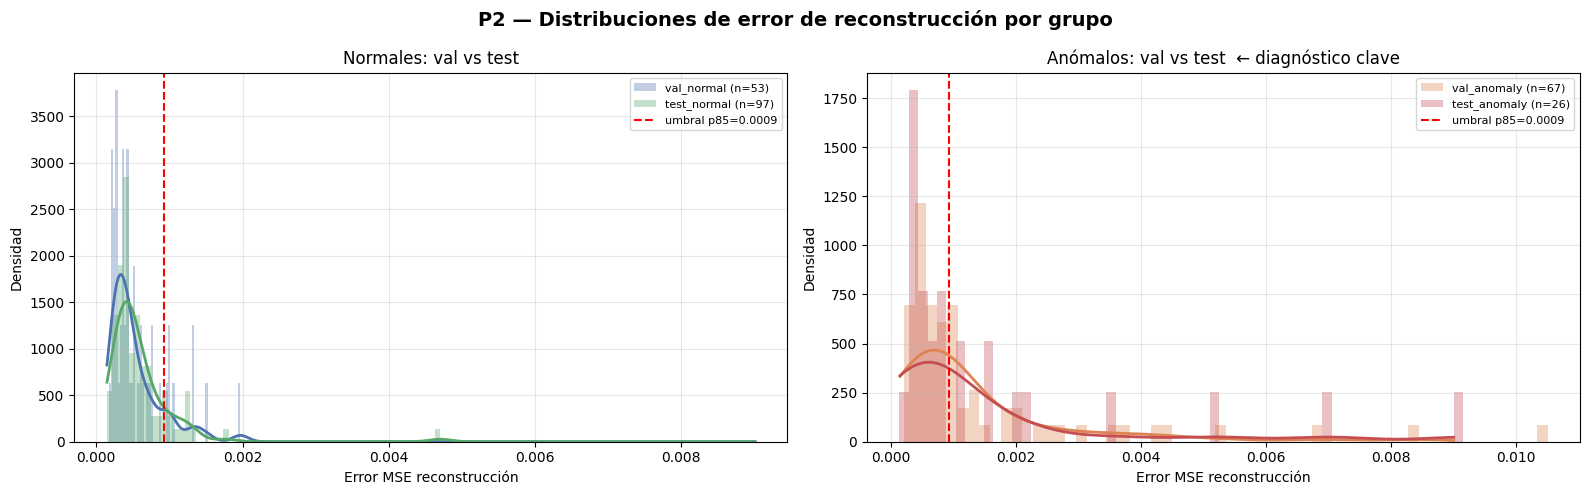


Estadísticas de error de reconstrucción (ventana):
  train_normal       n=  277  median=0.0005  p75=0.0007  p95=0.0015  >thr=15.2%
  val_normal         n=   53  median=0.0004  p75=0.0006  p95=0.0013  >thr=15.1%
  val_anomaly        n=   67  median=0.0008  p75=0.0014  p95=0.0050  >thr=44.8%
  test_normal        n=   97  median=0.0004  p75=0.0007  p95=0.0012  >thr=14.4%
  test_anomaly       n=   26  median=0.0007  p75=0.0016  p95=0.0066  >thr=38.5%


In [6]:
def kde_line(data, x_range):
    """Calcula KDE sobre data en el rango dado."""
    if len(data) < 2:
        return x_range, np.zeros_like(x_range)
    try:
        kde = gaussian_kde(data, bw_method=0.3)
        return x_range, kde(x_range)
    except Exception:
        return x_range, np.zeros_like(x_range)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
fig.suptitle("P2 — Distribuciones de error de reconstrucción por grupo", fontsize=14, fontweight="bold")

groups = [
    ("val_normal",   val_normal_errors,   "#4C72B0", 0.5),
    ("val_anomaly",  val_anomaly_errors,  "#DD8452", 0.7),
    ("test_normal",  test_normal_errors,  "#55A868", 0.5),
    ("test_anomaly", test_anomaly_errors, "#C44E52", 0.7),
]

all_errors = np.concatenate([g[1] for g in groups])
x_min, x_max = np.percentile(all_errors, 0.5), np.percentile(all_errors, 99.5)
x_range = np.linspace(x_min, x_max, 400)

# Subplot izq: val vs test, NORMAL
ax = axes[0]
ax.set_title("Normales: val vs test")
for name, errs, color, alpha in [("val_normal", val_normal_errors, "#4C72B0", 0.6),
                                  ("test_normal", test_normal_errors, "#55A868", 0.6)]:
    ax.hist(errs, bins=60, density=True, alpha=0.35, color=color, label=f"{name} (n={len(errs)})")
    xr, ky = kde_line(errs, x_range)
    ax.plot(xr, ky, color=color, lw=2)
ax.axvline(best_threshold, color="red", lw=1.5, ls="--", label=f"umbral p85={best_threshold:.4f}")
ax.set_xlabel("Error MSE reconstrucción")
ax.set_ylabel("Densidad")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Subplot der: val_anomaly vs test_anomaly — CLAVE
ax = axes[1]
ax.set_title("Anómalos: val vs test  ← diagnóstico clave")
for name, errs, color, alpha in [("val_anomaly", val_anomaly_errors, "#DD8452", 0.6),
                                  ("test_anomaly", test_anomaly_errors, "#C44E52", 0.6)]:
    ax.hist(errs, bins=60, density=True, alpha=0.35, color=color, label=f"{name} (n={len(errs)})")
    xr, ky = kde_line(errs, x_range)
    ax.plot(xr, ky, color=color, lw=2)
ax.axvline(best_threshold, color="red", lw=1.5, ls="--", label=f"umbral p85={best_threshold:.4f}")
ax.set_xlabel("Error MSE reconstrucción")
ax.set_ylabel("Densidad")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../plots/02_p2_error_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Estadísticas descriptivas
print("\nEstadísticas de error de reconstrucción (ventana):")
for name, errs in [("train_normal",  train_errors),
                   ("val_normal",    val_normal_errors),
                   ("val_anomaly",   val_anomaly_errors),
                   ("test_normal",   test_normal_errors),
                   ("test_anomaly",  test_anomaly_errors)]:
    pct_above = (errs > best_threshold).mean() * 100
    print(f"  {name:<18} n={len(errs):>5}  "
          f"median={np.median(errs):.4f}  "
          f"p75={np.percentile(errs,75):.4f}  "
          f"p95={np.percentile(errs,95):.4f}  "
          f">thr={pct_above:.1f}%")

---
## Pregunta 3 — Inspección visual de series temporales

- **Fila superior:** 3 anomalías de val con **score más alto** (bien detectadas)
- **Fila inferior:** 3 anomalías de test con **score más bajo** (peor detectadas, falsos negativos)

¿Son patrones visualmente distintos?

In [7]:
# Puntuaciones a nivel de segmento para anómalos
# Val anomaly — top 3 por score
val_anom_ids  = val_anomaly_segs
val_anom_scores = {sid: sc_val[uid_val == sid][0] for sid in val_anom_ids if sid in uid_val}
top_val = sorted(val_anom_scores, key=val_anom_scores.get, reverse=True)[:3]

# Test anomaly — bottom 3 por score (peor detectados)
test_anom_ids  = test_anomaly_segs
test_anom_scores = {sid: sc_test[uid_test == sid][0] for sid in test_anom_ids if sid in uid_test}
bottom_test = sorted(test_anom_scores, key=test_anom_scores.get)[:3]

print("Val anomaly top 3 (mejor detectados):")
for sid in top_val:
    print(f"  seg={sid}  score={val_anom_scores[sid]:.4f}  thr={best_threshold:.4f}  detección: {'✓' if val_anom_scores[sid]>best_threshold else '✗'}")

print("\nTest anomaly bottom 3 (peor detectados):")
for sid in bottom_test:
    print(f"  seg={sid}  score={test_anom_scores[sid]:.4f}  thr={best_threshold:.4f}  detección: {'✓' if test_anom_scores[sid]>best_threshold else '✗'}")

Val anomaly top 3 (mejor detectados):
  seg=1815  score=0.0105  thr=0.0009  detección: ✓
  seg=1186  score=0.0069  thr=0.0009  detección: ✓
  seg=1810  score=0.0044  thr=0.0009  detección: ✓

Test anomaly bottom 3 (peor detectados):
  seg=1953  score=0.0004  thr=0.0009  detección: ✗
  seg=1955  score=0.0004  thr=0.0009  detección: ✗
  seg=1183  score=0.0007  thr=0.0009  detección: ✗


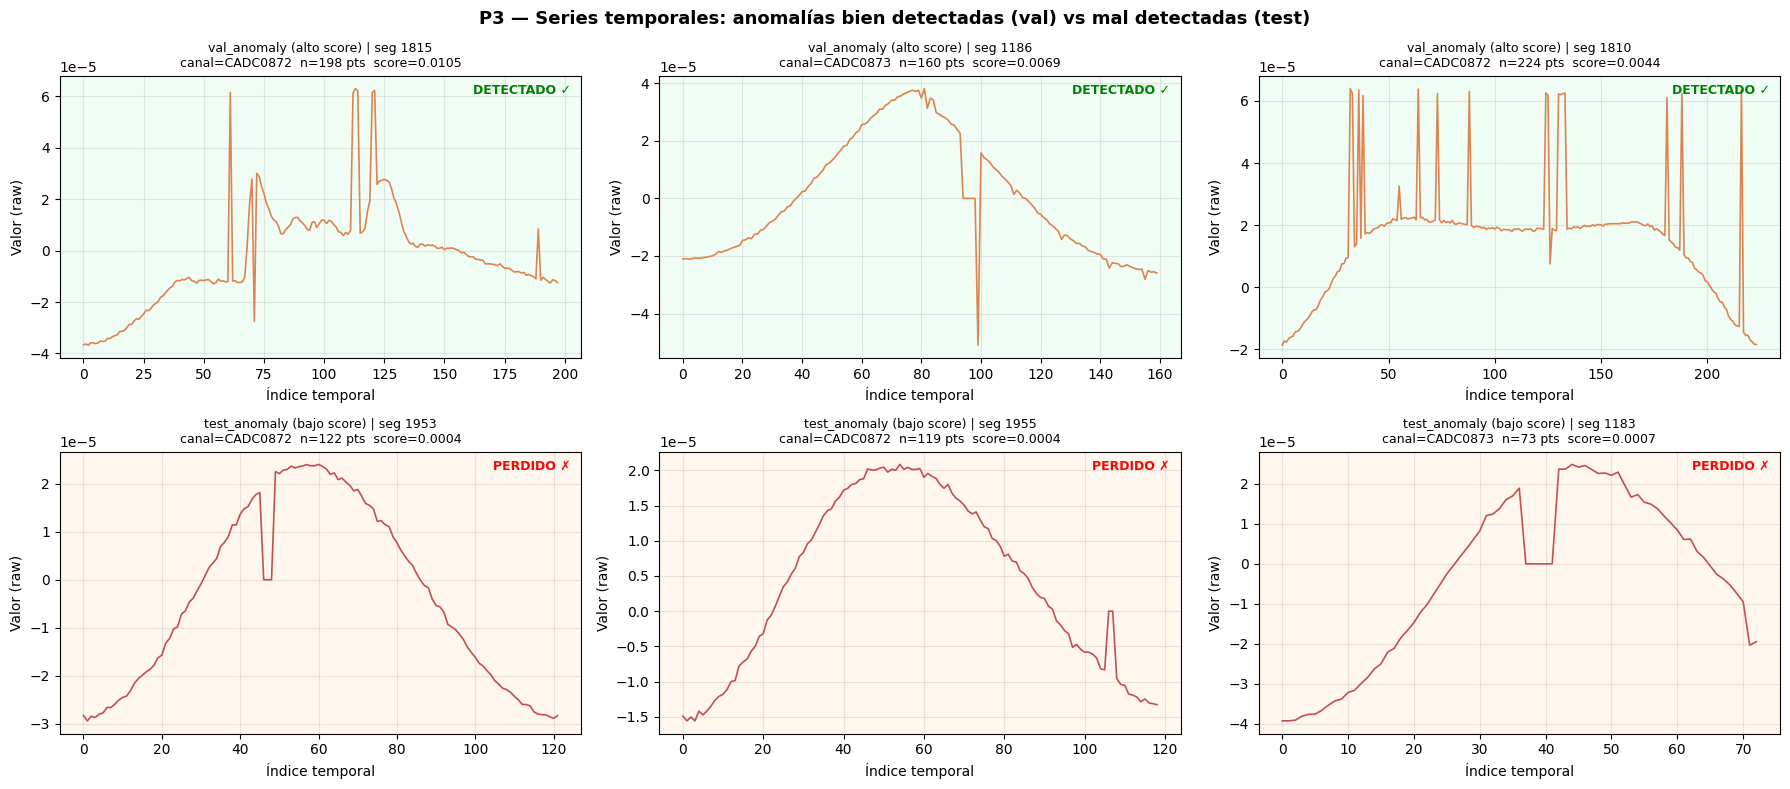

In [8]:
# Cargar series crudas completas
seg_df_full = load_opssat_segments()
# Filtrar a sampling=5
seg_df5 = seg_df_full[seg_df_full["sampling"] == CFG["sampling"]]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
fig.suptitle(
    "P3 — Series temporales: anomalías bien detectadas (val) vs mal detectadas (test)",
    fontsize=13, fontweight="bold"
)

def plot_segment(ax, seg_id, score, threshold, label, row_label, color):
    seg = seg_df5[seg_df5["segment"] == seg_id].sort_values("timestamp")
    channel = seg["channel"].iloc[0] if len(seg) > 0 else "?"
    values  = seg["value"].to_numpy()
    ax.plot(values, color=color, lw=1.2)
    ax.set_title(
        f"{row_label} | seg {seg_id}\n"
        f"canal={channel}  n={len(values)} pts  score={score:.4f}",
        fontsize=9
    )
    detected = score > threshold
    status   = "DETECTADO ✓" if detected else "PERDIDO ✗"
    ax.set_facecolor("#fff7ed" if not detected else "#f0fdf4")
    ax.text(0.98, 0.97, status, transform=ax.transAxes,
            ha="right", va="top", fontsize=9,
            color="green" if detected else "red", fontweight="bold")
    ax.set_xlabel("Índice temporal")
    ax.set_ylabel("Valor (raw)")
    ax.grid(alpha=0.3)

# Fila 0: val anomaly top 3
for j, sid in enumerate(top_val):
    plot_segment(axes[0, j], sid, val_anom_scores[sid], best_threshold,
                 label=1, row_label="val_anomaly (alto score)", color="#DD8452")

# Fila 1: test anomaly bottom 3
for j, sid in enumerate(bottom_test):
    plot_segment(axes[1, j], sid, test_anom_scores[sid], best_threshold,
                 label=1, row_label="test_anomaly (bajo score)", color="#C44E52")

plt.tight_layout()
plt.savefig("../plots/02_p3_visual_inspection.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Análisis complementario: anomaly rate por canal en val vs test

In [9]:
# Para cada grupo, calcular tasa de anomalía y scores medios por canal
def segment_scores_with_meta(seg_ids, seg_scores, seg_labels):
    """Crea DataFrame con score, label y metadata por segmento."""
    rows = []
    for sid, score, label in zip(seg_ids, seg_scores, seg_labels):
        meta = seg_meta5[seg_meta5["segment"] == sid]
        channel = meta["channel"].iloc[0] if len(meta) > 0 else "unknown"
        rows.append({"segment": sid, "score": score, "label": label,
                     "channel": channel, "detected": int(score > best_threshold)})
    return pd.DataFrame(rows)

val_df  = segment_scores_with_meta(uid_val,  sc_val,  lbl_val)
test_df = segment_scores_with_meta(uid_test, sc_test, lbl_test)

print("=== DETECCIÓN POR CANAL — VAL ===")
val_anom_by_ch = (
    val_df[val_df["label"]==1]
    .groupby("channel")
    .agg(n=("label","count"), detected=("detected","sum"), score_med=("score","median"))
)
val_anom_by_ch["recall"] = val_anom_by_ch["detected"] / val_anom_by_ch["n"]
print(val_anom_by_ch.to_string())

print("\n=== DETECCIÓN POR CANAL — TEST ===")
test_anom_by_ch = (
    test_df[test_df["label"]==1]
    .groupby("channel")
    .agg(n=("label","count"), detected=("detected","sum"), score_med=("score","median"))
)
test_anom_by_ch["recall"] = test_anom_by_ch["detected"] / test_anom_by_ch["n"]
print(test_anom_by_ch.to_string())

=== DETECCIÓN POR CANAL — VAL ===
           n  detected  score_med    recall
channel                                    
CADC0872  15        10   0.001318  0.666667
CADC0873   7         5   0.001006  0.714286
CADC0888  11         4   0.000557  0.363636
CADC0894   2         0   0.000434  0.000000

=== DETECCIÓN POR CANAL — TEST ===
          n  detected  score_med    recall
channel                                   
CADC0872  8         5   0.001311  0.625000
CADC0873  3         1   0.000742  0.333333


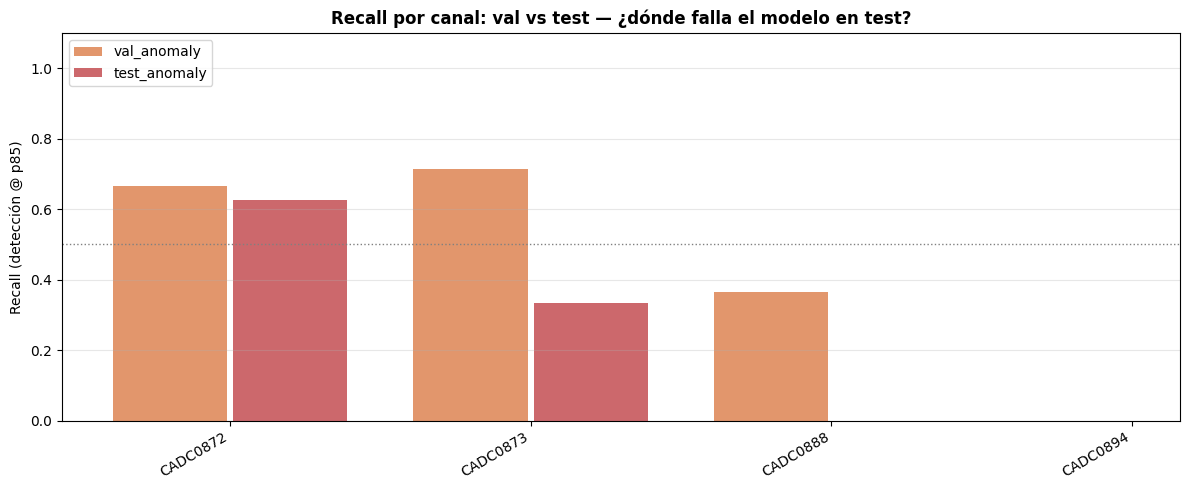

In [10]:
# Gráfico de recall por canal: val vs test
all_channels = sorted(set(val_anom_by_ch.index) | set(test_anom_by_ch.index))
val_recall  = [val_anom_by_ch.loc[ch,  "recall"] if ch in val_anom_by_ch.index  else np.nan for ch in all_channels]
test_recall = [test_anom_by_ch.loc[ch, "recall"] if ch in test_anom_by_ch.index else np.nan for ch in all_channels]

x = np.arange(len(all_channels))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.2, val_recall,  0.38, label="val_anomaly",  color="#DD8452", alpha=0.85)
ax.bar(x + 0.2, test_recall, 0.38, label="test_anomaly", color="#C44E52", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(all_channels, rotation=30, ha="right")
ax.set_ylabel("Recall (detección @ p85)")
ax.set_title("Recall por canal: val vs test — ¿dónde falla el modelo en test?", fontweight="bold")
ax.set_ylim(0, 1.1)
ax.axhline(0.5, color="gray", ls=":", lw=1)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../plots/02_p1b_recall_by_channel.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Diagnóstico final

> Completa esta celda markdown **después de ejecutar el notebook** con los hallazgos observados.

### Hallazgos observados

**P1 — Canal:**
No hay canales exclusivos de `test_anomaly` (`only_in_test = []`).
Sin embargo, `val_anomaly` tiene **4 canales** (CADC0872×15, CADC0873×7, CADC0888×11, CADC0894×2)
mientras que `test_anomaly` tiene solo **2** (CADC0872×8, CADC0873×3).
Más crítico: el ratio anomalía/total es **47% en val** (35/74 segmentos) vs **15% en test** (11/72 segs) —
un imbalance de clases masivo entre splits.

**P2 — Distribuciones de error:**
Las medianas de `val_anomaly` (0.0008) y `test_anomaly` (0.0007) son casi idénticas.
Porcentaje de ventanas sobre el umbral: 44.8% en val_anomaly vs 38.5% en test_anomaly — similares.
**La distribución de errores de las anomalías NO es radicalmente distinta.** El modelo genera scores
comparables en ambos splits. El problema es que hay 61 normales en test (vs 39 en val) generando
falsos positivos que colapsan la precisión cuando la base de anomalías es tan pequeña (11 segs).

**P3 — Visual:**
Los 3 de val mejor detectados (scores 0.0105, 0.0069, 0.0044) son segmentos largos (198–224 pts) de CADC0872/CADC0873.
Los 3 de test peor detectados (scores 0.0004, 0.0004, 0.0007) son más cortos (73–122 pts) del mismo canal.
Post z-score por segmento los patrones parecen planos — segmentos cortos producen pocas ventanas
de error alto independientemente del tipo de anomalía.

---

### Diagnóstico

**¿Es problema de canal, tipo de anomalía, o cantidad de datos?**
**Principalmente imbalance de clases entre val y test, agravado por escasez de datos.**
Val: 47% anomalías (35/74 segs). Test: 15% anomalías (11/72 segs).
El umbral se calibra en un set casi balanceado, pero con 15% de anomalías el mismo umbral produce
muchos más FPs relativos a TPs — precision colapsa. Hay además solo 11 segmentos anómalos en test,
demasiado poco para estimaciones estables. El modelo sí discrimina (AUC-ROC 0.779).

**Recomendación concreta:**
1. **Recalibrar umbral con ratio real (~15%):** usar un val set con la misma proporción anomalía/normal
   que el test, o aplicar Platt scaling sobre los scores. No requiere Optuna.
2. **Añadir cohort sampling=1 de inmediato:** 793 segmentos 1 Hz multiplican el test set disponible;
   las métricas dejarán de ser tan ruidosas con solo 11 anomalías en test.
3. **Optuna solo si el gap persiste tras los puntos 1–2:** la arquitectura discrimina bien;
   el problema es el umbral y el tamaño del test set, no la capacidad del modelo.

**Justificación en una frase:**
El AUC-ROC se mantiene en test (0.779) y los errores de val_anomaly/test_anomaly tienen distribuciones
casi idénticas (medianas 0.0008 vs 0.0007), confirmando que el modelo detecta bien — el colapso de
F0.5 es consecuencia del imbalance 47%→15% entre val y test, no de anomalías de tipo distinto.

---
*Notebook de diagnóstico — no modifica ningún modelo ni parámetro. Solo análisis.*